## Regresion lineal multiple

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns


In [9]:
data = sns.load_dataset("diamonds")
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [10]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [11]:
data.shape

(53940, 10)

In [19]:
print(data.isnull().sum())

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


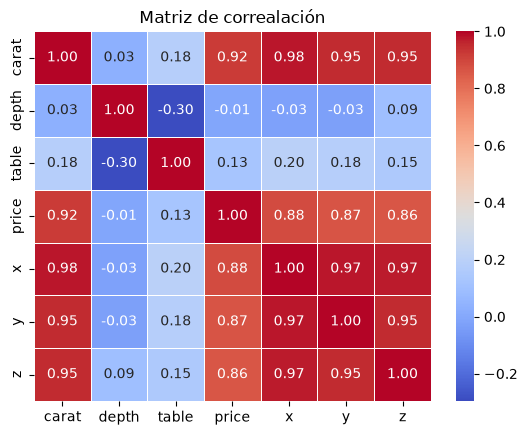

In [20]:
# Matriz de correlacion

corr_matriz = data.corr(numeric_only=True)

sns.heatmap(corr_matriz, annot= True, cmap = "coolwarm", fmt=".2f", linewidths= 0.5)
plt.title("Matriz de correalación")
plt.show()


In [23]:
data = data.dropna()

x = data[["carat", "table"]]
y = data["price"]

# 70% entrenamiento
# 30% prueba

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.3, random_state= 42)



In [25]:
model = LinearRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
r2 = r2_score(y_test, y_predict)
rms = mean_squared_error(y_test, y_predict)**(1/2)

In [26]:
print("Coeficientes del modelo : ", model.coef_)
print("Intercepto : ", model.intercept_)
print(f"r2 del modelo :  {r2:.2f}")
print(f"Error cuadratico medio : {rms:.2f}")

Coeficientes del modelo :  [7828.41047886  -76.05399153]
Intercepto :  2060.770743616251
r2 del modelo :  0.85
Error cuadratico medio : 1528.36


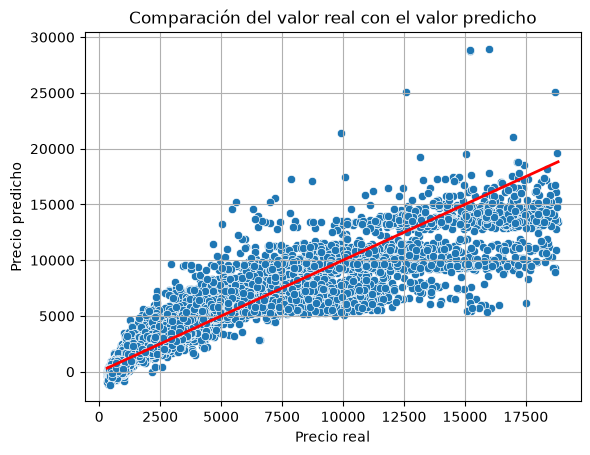

In [27]:
sns.scatterplot(x = y_test, y = y_predict)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, color = "red", linewidth = 2 )
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Comparación del valor real con el valor predicho")
plt.grid()
plt.show()

